In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score , precision_score , recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers , losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model


(xtrain , _) , (xtest , _) = fashion_mnist.load_data()

xtrain = xtrain.astype('float32')/255.
xtest = xtest.astype('float32')/255.



xtrain = xtrain[... , tf.newaxis]
xtest = xtest[... , tf.newaxis]


print(xtrain.shape)

4422102/4422102 [==============================] - 0s 0us/step
(60000, 28, 28, 1)


In [ ]:
noise_factor = 0.2

xtrain_noisy = xtrain + noise_factor * tf.random.normal(shape = xtrain.shape)
xtest_noisy = xtest + noise_factor * tf.random.normal(shape = xtest.shape)


xtrain_noisy = tf.clip_by_value(xtrain_noisy , clip_value_min = 0. , clip_value_max=1.)
xtest_noisy = tf.clip_by_value(xtest_noisy , clip_value_min = 0. , clip_value_max=1.)

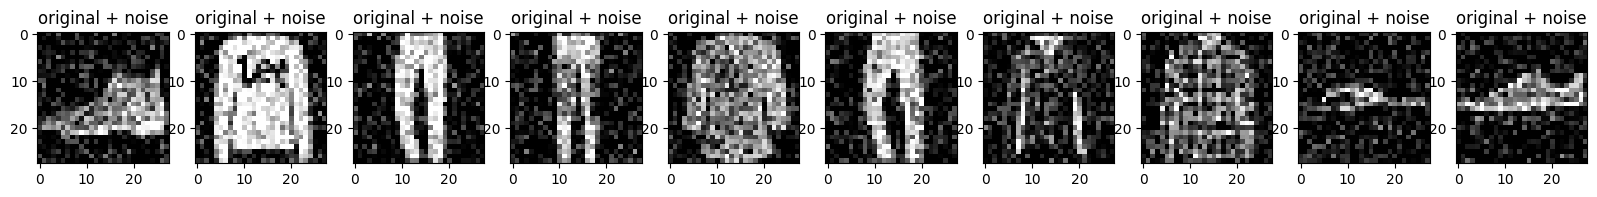

In [ ]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(xtest_noisy[i]))
    plt.gray()
plt.show()

In [ ]:
class Denoise(Model):
  def __init__(self):
    super(Denoise, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
      layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)])

    self.decoder = tf.keras.Sequential([
      layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
      layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = Denoise()

In [ ]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [ ]:
autoencoder.fit(xtrain_noisy, xtrain,
                epochs=10,
                shuffle=True,
                validation_data=(xtest_noisy, xtest))

Epoch 1/10
1875/1875 [==============================] - 13s 4ms/step - loss: 0.0183 - val_loss: 0.0109
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0099 - val_loss: 0.0092
Epoch 3/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0088 - val_loss: 0.0086
Epoch 4/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0083 - val_loss: 0.0082
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0081 - val_loss: 0.0080
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0079 - val_loss: 0.0079
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0078 - val_loss: 0.0078
Epoch 8/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0077 - val_loss: 0.0077
Epoch 9/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 10/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.00

In [ ]:
autoencoder.encoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 16)        160       
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 8)           1160      
                                                                 
Total params: 1320 (5.16 KB)
Trainable params: 1320 (5.16 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
autoencoder.encoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 16)        160       
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 8)           1160      
                                                                 
Total params: 1320 (5.16 KB)
Trainable params: 1320 (5.16 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
encoded_imgs = autoencoder.encoder(xtest_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

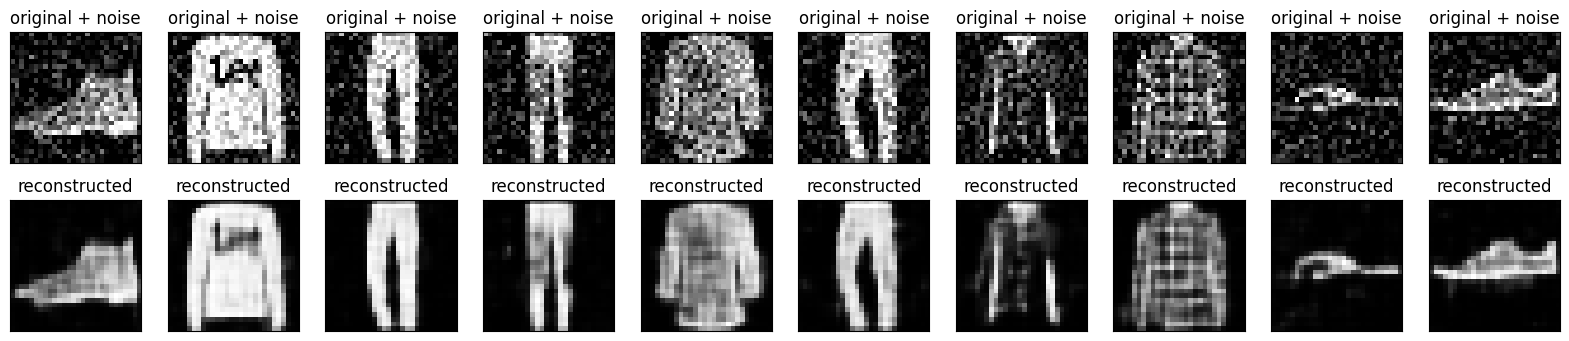

In [ ]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):

    # display original + noise
    ax = plt.subplot(2, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(xtest_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    bx = plt.subplot(2, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()